# Estrategia 1 — EfficientNet B0–B7 + NAS en el clasificador

In [1]:
# 1. Montar Drive y clonar/actualizar repo
from google.colab import drive
drive.mount('/content/drive')

import os
repo_path = '/content/darts-cards'
if not os.path.exists(repo_path):
    !git clone https://github.com/javiergarciaduran/darts-cards.git {repo_path}
else:
    !git -C {repo_path} pull
%cd {repo_path}

Mounted at /content/drive
Cloning into '/content/darts-cards'...
remote: Enumerating objects: 260, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 260 (delta 80), reused 99 (delta 50), pack-reused 110 (from 1)
Receiving objects: 100% (260/260), 11.88 MiB | 19.81 MiB/s, done.
Resolving deltas: 100% (124/124), done.
/content/darts-cards


In [2]:
# 2. Dependencias
!pip install -q torchvision
!pip install -q scikit-learn matplotlib

In [3]:
# 3. Fix encoding
!iconv -f UTF-16 -t UTF-8 /content/darts-cards/datasets/__init__.py > temp.py && mv temp.py /content/darts-cards/datasets/__init__.py

In [4]:
# 4. Symlink dataset
!mkdir -p ./data
!ln -sfn /content/drive/MyDrive/cards ./data/cards

# Verificar
from datasets.cards import get_cards
tr, nc = get_cards('./data/cards', input_size=224, split='train')
va, _  = get_cards('./data/cards', input_size=224, split='val')
print(f'train={len(tr)}  val={len(va)}  classes={nc}')

train=7640  val=265  classes=53


In [5]:
# 5. Crear carpetas de salida en Drive
!mkdir -p /content/drive/MyDrive/darts_experiments/efficientnet
!mkdir -p /content/drive/MyDrive/darts_logs/efficientnet

## B0 — empezar aquí (el más ligero, ~5 min)
Ejecuta primero B0 para verificar que todo funciona. Luego escala a B1–B7.

In [10]:
!python efficientnet_search.py \
    --backbone efficientnet_b0 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 50 \
    --batch_size 128 \
    --hidden 256 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b0.log

2026-06-30 16:13:59,229 | Backbone: efficientnet_b0 | device: cuda | out: /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b0_seed42
2026-06-30 16:14:00,284 | Clases: 53 | train=7640 val=265
2026-06-30 16:14:00,706 | Backbone: 4.01M params (congelado) | Clasificador NAS: 1.3668M params (entrenable)
2026-06-30 16:41:06,311 | Epoch [  1/50] train_acc=23.12%  val_acc=41.89%  genotype={'op1': 'linear', 'op2': 'linear_bn_relu'}
2026-06-30 16:41:51,532 | Epoch [  2/50] train_acc=39.51%  val_acc=47.55%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 16:42:20,968 | Epoch [  3/50] train_acc=50.00%  val_acc=53.21%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 16:42:50,381 | Epoch [  4/50] train_acc=57.65%  val_acc=52.83%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 16:43:19,275 | Epoch [  5/50] train_acc=61.85%  val_acc=56.23%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 16:43:48,790 | Epoch [  6/50] train_acc=66.11%  val_acc=59.62%  geno

In [11]:
!python efficientnet_search.py \
    --backbone efficientnet_b4 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 100 \
    --batch_size 32 \
    --hidden 512 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b4.log

2026-06-30 17:05:25,623 | Backbone: efficientnet_b4 | device: cuda | out: /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b4_seed42
2026-06-30 17:05:26,448 | Clases: 53 | train=7640 val=265
2026-06-30 17:05:27,170 | Backbone: 17.55M params (congelado) | Clasificador NAS: 3.7820M params (entrenable)
2026-06-30 17:06:13,923 | Epoch [  1/100] train_acc=30.34%  val_acc=46.79%  genotype={'op1': 'linear_bn_relu', 'op2': 'linear'}
2026-06-30 17:07:01,909 | Epoch [  2/100] train_acc=54.69%  val_acc=58.87%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 17:07:50,160 | Epoch [  3/100] train_acc=65.93%  val_acc=71.70%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 17:08:37,849 | Epoch [  4/100] train_acc=73.29%  val_acc=71.70%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 17:09:24,026 | Epoch [  5/100] train_acc=78.43%  val_acc=67.17%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-30 17:10:10,828 | Epoch [  6/100] train_acc=80.97%  val_acc=63.77

In [ ]:
!python efficientnet_search.py \
    --backbone efficientnet_b7 \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/efficientnet \
    --epochs 100 \
    --batch_size 32 \
    --hidden 1024 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/efficientnet/b7_sin_skip_1024.log

2026-06-21 13:51:56,923 | Backbone: efficientnet_b7 | device: cuda | out: /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b7_seed42
2026-06-21 13:51:57,964 | Clases: 53 | train=7640 val=265
Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth
100%|██████████| 255M/255M [00:01<00:00, 243MB/s]
2026-06-21 13:52:01,186 | Backbone: 63.79M params (congelado) | Clasificador NAS: 10.7093M params (entrenable)
2026-06-21 14:15:12,614 | Epoch [  1/100] train_acc=25.41%  val_acc=38.49%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-21 14:18:04,499 | Epoch [  2/100] train_acc=42.59%  val_acc=46.42%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-21 14:20:55,170 | Epoch [  3/100] train_acc=51.34%  val_acc=55.85%  genotype={'op1': 'linear', 'op2': 'linear'}
2026-06-21 14:23:42,655 | Epoch [  4/100] train_acc=55.61%  val_acc=53.96%  genotype={'op1': 'linear', 

## Evaluación en test set — ejecutar UNA SOLA VEZ por backbone
Cambia `BACKBONE` según el modelo que quieras evaluar.

In [12]:
BACKBONE = 'efficientnet_b0'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

Backbone  : efficientnet_b0
Hidden    : 256
Input size: 224
Genotype  : {'op1': 'linear_relu', 'op2': 'linear'}
Best val  : 68.30%  (epoch 31)
Parameters: 5.37 M
Test Top-1 accuracy : 61.89%
Test Top-5 accuracy : 89.06%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b0_seed42/test_results.json
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b0_seed42/confusion_matrix.png
Figure(1600x1400)


In [13]:
BACKBONE = 'efficientnet_b4'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

Backbone  : efficientnet_b4
Hidden    : 512
Input size: 380
Genotype  : {'op1': 'linear_relu', 'op2': 'linear'}
Best val  : 77.36%  (epoch 70)
Parameters: 21.33 M
Test Top-1 accuracy : 72.83%
Test Top-5 accuracy : 94.34%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b4_seed42/test_results.json
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b4_seed42/confusion_matrix.png
Figure(1600x1400)


In [14]:
BACKBONE = 'efficientnet_b7'

!python efficientnet_evaluate.py \
    --checkpoint /content/drive/MyDrive/darts_experiments/efficientnet/{BACKBONE}_seed42/best.pth.tar \
    --data_path ./data/cards

Backbone  : efficientnet_b7
Hidden    : 1024
Input size: 600
Genotype  : {'op1': 'linear_relu', 'op2': 'linear_relu'}
Best val  : 73.58%  (epoch 88)
Parameters: 74.50 M
Test Top-1 accuracy : 69.43%
Test Top-5 accuracy : 89.43%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b7_seed42/test_results.json
Saved → /content/drive/MyDrive/darts_experiments/efficientnet/efficientnet_b7_seed42/confusion_matrix.png
Figure(1600x1400)


## Comparativa Estrategia 1 vs Estrategia 2

efficientnet_b0            test_top1=61.89%  val_acc=68.30%  genotype={'op1': 'linear_relu', 'op2': 'linear'}
efficientnet_b4            test_top1=72.83%  val_acc=77.36%  genotype={'op1': 'linear_relu', 'op2': 'linear'}
efficientnet_b7            test_top1=69.43%  val_acc=73.58%  genotype={'op1': 'linear_relu', 'op2': 'linear_relu'}


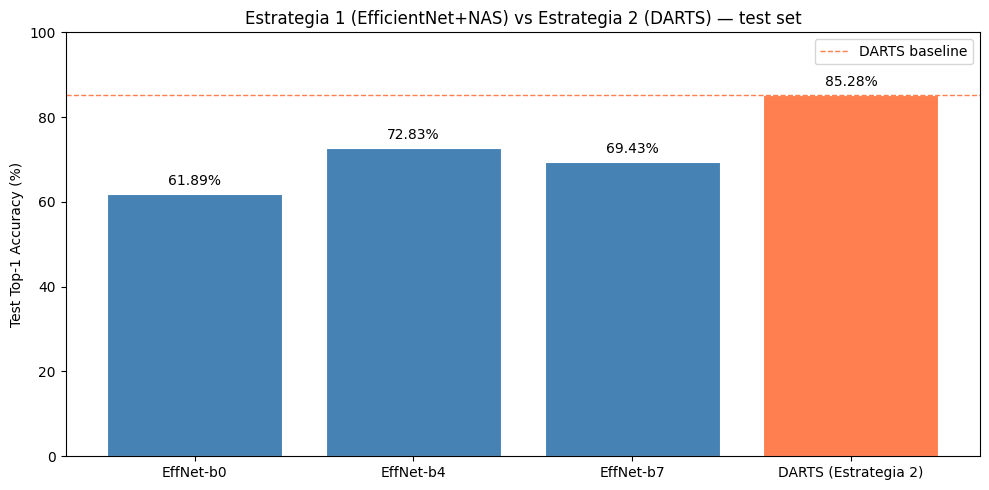

In [15]:
import os, json
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/darts_experiments/efficientnet'
backbones = ['efficientnet_b0', 'efficientnet_b4', 'efficientnet_b7']

# Usamos test_top1 (test_results.json, generado por efficientnet_evaluate.py)
# en vez de val_acc: val_acc se usa también para actualizar los alphas de
# arquitectura durante la búsqueda, por lo que no es una métrica "limpia" de
# generalización. test_top1 nunca interviene en la optimización.
results = []
for bb in backbones:
    results_path = os.path.join(BASE, f'{bb}_seed42', 'test_results.json')
    if os.path.exists(results_path):
        with open(results_path) as f:
            r = json.load(f)
        results.append({'backbone': bb, 'test_acc': r['test_top1'], 'genotype': r['genotype']})
        print(f"{bb:25s}  test_top1={r['test_top1']:.2f}%  val_acc={r['val_acc']:.2f}%  genotype={r['genotype']}")
    else:
        print(f"{bb:25s}  — falta test_results.json (ejecuta efficientnet_evaluate.py)")

# Añadir resultado DARTS (Estrategia 2) para comparar.
# NOTA: para que la comparación sea consistente, este valor debe ser también
# una accuracy de TEST (no de validación) de la fase augment.py.
results.append({'backbone': 'DARTS (Estrategia 2)', 'test_acc': 85.28})

labels  = [r['backbone'].replace('efficientnet_', 'EffNet-') for r in results]
accs    = [r['test_acc'] for r in results]
colors  = ['steelblue'] * (len(results)-1) + ['coral']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=10)
ax.set_ylim(0, 100)
ax.set_ylabel('Test Top-1 Accuracy (%)')
ax.set_title('Estrategia 1 (EfficientNet+NAS) vs Estrategia 2 (DARTS) — test set')
ax.axhline(85.28, color='coral', linestyle='--', linewidth=1, label='DARTS baseline')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'comparison.png'), dpi=150)
plt.show()